Analisis yang akan dilakukan berdasarkan [Sumber Dataset](https://mavenanalytics.io/data-playground/toy-store-e-commerce-database) :

1. Bagaimana tren jumlah kunjungan/sesi di website dan volume pesanan?
2. Berapa tingkat konversi dari kunjungan website menjadi pesanan? Bagaimana trennya dari waktu ke waktu?
3. Saluran pemasaran (marketing channel) mana yang paling berhasil/efektif?
4. Bagaimana perkembangan pendapatan rata-rata per pesanan? Bagaimana dengan pendapatan rata-rata per kunjungan/sesi website?

# Persiapan

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

# Data Wrangling

## Gathering Data

### Dictionary Setiap Kolom di Dataset

In [3]:
maven_fuzzy_factory_data_dictionary_df = pd.read_csv("https://raw.githubusercontent.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/refs/heads/main/dataset/maven_fuzzy_factory_data_dictionary.csv")
maven_fuzzy_factory_data_dictionary_df

,Table,Field,Description
0,orders,order_id,Unique identifier for each order (PK)
1,orders,created_at,Timestamp when the order was placed
2,orders,website_session_id,Unique identifier for the website session (FK)
3,orders,user_id,Unique identifier for the user (FK)
4,orders,primary_product_id,Unique identifier for the primary product in the order if part of a bundle (FK)
5,orders,items_purchased,Number of items in the order
6,orders,price_usd,Total price for the items in the order
7,orders,cogs_usd,Cost of goods sold for the items in the order
8,order_items,order_item_id,Unique identifier for each order item (PK)
9,order_items,created_at,Timestamp when the order was placed


![Relasi Antar Tabel](https://github.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/raw/main/relasi-antar-tabel.png)

### Tabel Orders


Tabel ini mencatat ringkasan total dari sebuah transaksi/pembelian yang berhasil.

In [4]:
orders_df = pd.read_csv("https://raw.githubusercontent.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/refs/heads/main/dataset/orders.csv")
orders_df.head()


,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


### Tabel Order Items

Tabel ini mencatat transaksi/pembelian yang berhasil per order item.


In [5]:
order_items_df = pd.read_csv("https://raw.githubusercontent.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/refs/heads/main/dataset/order_items.csv")
order_items_df.head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49


**Bedanya dengan tabel orders?**

Dapat dilihat dibawah ini pada tabel `orders`.  
Pada `order_id` nomor ke-7300, catatan HANYA MENULISKAN bahwa memesan sebanyak 2 buah item tanpa detail barang apa yang dibeli

In [6]:
orders_df[orders_df['items_purchased'] > 1].head()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
7299,7300,2013-09-25 08:49:13,132876,116186,1,2,109.98,41.98
7301,7302,2013-09-25 12:50:39,132965,116266,1,2,109.98,41.98
7309,7310,2013-09-25 17:30:15,133099,116378,1,2,109.98,41.98
7351,7352,2013-09-27 01:40:13,133588,103416,2,2,109.98,41.98
7375,7376,2013-09-28 10:21:27,133996,88820,1,2,109.98,41.98


Sedangkan pada tabel `order_item`, dapat dilihat dengan detail barang yang dibeli pada `order_id` ke 7300 adalah `product_id` 1 dan 2

In [7]:
order_items_df[order_items_df['order_id'] == 7300].head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
7299,7300,2013-09-25 08:49:13,7300,1,1,49.99,19.49
7300,7301,2013-09-25 08:49:13,7300,2,0,59.99,22.49


### Tabel Order Item Refunds

Tabel ini mencatat barang spesifik yang dikembalikan oleh pelanggan (refund).

In [8]:
order_item_refunds_df = pd.read_csv("https://raw.githubusercontent.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/refs/heads/main/dataset/order_item_refunds.csv")
order_item_refunds_df.head()

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99


### Tabel Products

Tabel ini berfungsi sebagai katalog atau master data barang yang dijual oleh toko.

In [9]:
products_df = pd.read_csv("https://raw.githubusercontent.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/refs/heads/main/dataset/products.csv")
products_df.head()

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


### Tabel Website Page Views


Tabel ini berfungsi mencatat halaman spesifik apa saja yang diklik/dilihat oleh pelanggan selama satu sesi kunjungan tersebut.

In [10]:
website_pageviews_df = pd.read_csv("https://raw.githubusercontent.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/refs/heads/main/dataset/website_pageviews.csv")
website_pageviews_df.head()

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home


### Tabel Website Session

Tabel ini berfungsi mencatat setiap kali seseorang mengunjungi website (satu kunjungan = satu sesi)

In [11]:
website_sessions_df = pd.read_csv("https://raw.githubusercontent.com/valselt/analisis-data-mavenanalytics-toystoreecommercedataset/refs/heads/main/dataset/website_sessions.csv")
website_sessions_df.head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


## Assessing Data

### Tabel Orders

In [12]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  object 
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 2.0+ MB


⚠️ PROBLEM: Tipe kolom `created_at` harusnya datetime

In [13]:
orders_df.isna().sum()

,0
order_id,0
created_at,0
website_session_id,0
user_id,0
primary_product_id,0
items_purchased,0
price_usd,0
cogs_usd,0


In [14]:
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

Jumlah duplikasi:  0


In [15]:
orders_df.describe()

,order_id,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
count,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000
mean,16157.000000,258292.288707,215691.622629,1.392474,1.238666,59.991636,22.355406
std,9328.103961,132427.649842,108402.203189,0.732277,0.426274,17.808771,6.238621
min,1.000000,20.000000,13.000000,1.000000,1.000000,29.990000,9.490000
25%,8079.000000,144828.000000,124135.000000,1.000000,1.000000,49.990000,19.490000
50%,16157.000000,263554.000000,221461.000000,1.000000,1.000000,49.990000,19.490000
75%,24235.000000,374799.000000,310542.000000,2.000000,1.000000,59.990000,22.490000
max,32313.000000,472818.000000,394273.000000,4.000000,2.000000,109.980000,41.980000


**💡Insight:**  
Kolom yang penting untuk dilihat adalah Kolom `items_purchased`,
`price_usd`, dan `cogs_usd` yang mempunyai Data Kuantitatif.

Cek Outlier sebelum IQR :
- Q3 (`75%`) dengan `max` jaraknya wajar? ✅
- Median/Q2 (`50%`) dengan `mean` jaraknya wajar? ✅
- Standar Deviasi (`std`) dengan `mean` jaraknya wajar?
- Nilai Minimum (`min`) karena pada data ini tidak mungkin ada yang negatif, apakah positif? ✅

Gausah Cek IQR lagi

**Step To Take :**  
Perbaiki tipe data `created_at`

### Tabel Order Items

In [16]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_item_id    40025 non-null  int64  
 1   created_at       40025 non-null  object 
 2   order_id         40025 non-null  int64  
 3   product_id       40025 non-null  int64  
 4   is_primary_item  40025 non-null  int64  
 5   price_usd        40025 non-null  float64
 6   cogs_usd         40025 non-null  float64
dtypes: float64(2), int64(4), object(1)
memory usage: 2.1+ MB


⚠️ PROBLEM: Tipe kolom `created_at` harusnya datetime

In [17]:
order_items_df.isna().sum()

,0
order_item_id,0
created_at,0
order_id,0
product_id,0
is_primary_item,0
price_usd,0
cogs_usd,0


In [18]:
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


In [19]:
order_items_df.describe()

,order_item_id,order_id,product_id,is_primary_item,price_usd,cogs_usd
count,40025.000000,40025.000000,40025.000000,40025.000000,40025.000000,40025.000000
mean,20013.000000,17121.957502,1.770019,0.807320,48.432473,18.047976
std,11554.366599,9053.765867,1.085561,0.394408,8.012370,3.856821
min,1.000000,1.000000,1.000000,0.000000,29.990000,9.490000
25%,10007.000000,9871.000000,1.000000,1.000000,49.990000,19.490000
50%,20013.000000,17490.000000,1.000000,1.000000,49.990000,19.490000
75%,30019.000000,24818.000000,2.000000,1.000000,49.990000,19.490000
max,40025.000000,32313.000000,4.000000,1.000000,59.990000,22.490000


**Steps To Take:**  
Perbaiki tipe data `created_at'

### Tabel Order Item Refunds

In [20]:
order_item_refunds_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1731 entries, 0 to 1730
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_item_refund_id  1731 non-null   int64  
 1   created_at            1731 non-null   object 
 2   order_item_id         1731 non-null   int64  
 3   order_id              1731 non-null   int64  
 4   refund_amount_usd     1731 non-null   float64
dtypes: float64(1), int64(3), object(1)
memory usage: 67.7+ KB


⚠️ PROBLEM: Tipe kolom `created_at` harusnya datetime

In [21]:
order_item_refunds_df.isna().sum()


,0
order_item_refund_id,0
created_at,0
order_item_id,0
order_id,0
refund_amount_usd,0


In [22]:
print("Jumlah duplikasi: ", order_item_refunds_df.duplicated().sum())

Jumlah duplikasi:  0


In [23]:
order_item_refunds_df.describe()

,order_item_refund_id,order_item_id,order_id,refund_amount_usd
count,1731.000000,1731.000000,1731.000000,1731.000000
mean,866.000000,18472.214905,15868.242057,49.300225
std,499.840975,11438.074606,9096.061945,4.956015
min,1.000000,57.000000,57.000000,29.990000
25%,433.500000,7417.000000,7412.000000,49.990000
50%,866.000000,19858.000000,17375.000000,49.990000
75%,1298.500000,26900.000000,22539.500000,49.990000
max,1731.000000,39950.000000,32255.000000,59.990000


**Steps To Take:**  
Perbaiki tipe data `created_at'

### Tabel Products

In [24]:
products_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_id    4 non-null      int64 
 1   created_at    4 non-null      object
 2   product_name  4 non-null      object
dtypes: int64(1), object(2)
memory usage: 228.0+ bytes


⚠️ PROBLEM: Tipe kolom `created_at` harusnya datetime

In [25]:
products_df.isna().sum()

,0
product_id,0
created_at,0
product_name,0


In [26]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


In [27]:
products_df.describe()

,product_id
count,4.000000
mean,2.500000
std,1.290994
min,1.000000
25%,1.750000
50%,2.500000
75%,3.250000
max,4.000000


**💡Insight:**  
Kolom `product_id` nilai `min` nya bukan negatif. Ini benar karena seharusnya tidak boleh minus.

**Steps To Take:**  
Perbaiki tipe data `created_at'

### Tabel Website Page Views

In [28]:
website_pageviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188124 entries, 0 to 1188123
Data columns (total 4 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   website_pageview_id  1188124 non-null  int64 
 1   created_at           1188124 non-null  object
 2   website_session_id   1188124 non-null  int64 
 3   pageview_url         1188124 non-null  object
dtypes: int64(2), object(2)
memory usage: 36.3+ MB


⚠️ PROBLEM: Tipe kolom `created_at` harusnya datetime:

In [29]:
website_pageviews_df.isna().sum()

,0
website_pageview_id,0
created_at,0
website_session_id,0
pageview_url,0


In [30]:
print("Jumlah duplikasi: ", website_pageviews_df.duplicated().sum())

Jumlah duplikasi:  0


In [31]:
website_pageviews_df.describe()

,website_pageview_id,website_session_id
count,1.188124e+06,1.188124e+06
mean,5.940625e+05,2.444585e+05
std,3.429820e+05,1.356199e+05
min,1.000000e+00,1.000000e+00
25%,2.970318e+05,1.277860e+05
50%,5.940625e+05,2.478080e+05
75%,8.910932e+05,3.627390e+05
max,1.188124e+06,4.728710e+05


**💡Insight:**  
Kolom `website_pageview_id` dan `website_sessions_id` nilai `min` nya bukan negatif. Ini benar karena seharusnya tidak boleh minus.

**Steps To Take:**  
Perbaiki tipe data `created_at'

### Tabel Website Session

In [32]:
website_sessions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   website_session_id  472871 non-null  int64 
 1   created_at          472871 non-null  object
 2   user_id             472871 non-null  int64 
 3   is_repeat_session   472871 non-null  int64 
 4   utm_source          389543 non-null  object
 5   utm_campaign        389543 non-null  object
 6   utm_content         389543 non-null  object
 7   device_type         472871 non-null  object
 8   http_referer        432954 non-null  object
dtypes: int64(3), object(6)
memory usage: 32.5+ MB


⚠️ PROBLEM: Tipe kolom `created_at` harusnya datetime:

In [33]:
website_sessions_df.isna().sum()

,0
website_session_id,0
created_at,0
user_id,0
is_repeat_session,0
utm_source,83328
utm_campaign,83328
utm_content,83328
device_type,0
http_referer,39917


⚠️ PROBLEM: Kolom `utm_source`, `utm_campaign`, `utm_content`, dan `http_referer` ini kolomnya kosong. Harus diperbaiki

In [34]:
print("Jumlah duplikasi: ", website_sessions_df.duplicated().sum())

Jumlah duplikasi:  0


In [35]:
website_sessions_df.describe()

,website_session_id,user_id,is_repeat_session
count,472871.000000,472871.000000,472871.000000
mean,236436.000000,198037.970163,0.166119
std,136506.243908,111992.997798,0.372188
min,1.000000,1.000000,0.000000
25%,118218.500000,101966.500000,0.000000
50%,236436.000000,199483.000000,0.000000
75%,354653.500000,294433.000000,0.000000
max,472871.000000,394318.000000,1.000000


**Steps To Take:**  
- Perbaiki tipe data `created_at'
- Perbaiki missing value pada `utm_source`, `utm_campaign`, `utm_content`, dan `http_referer`

### Cek Relasi product_id

#### Cek Apakah Ada product_id > 4

In [36]:
orders_df[orders_df['primary_product_id'] > 4]

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd


In [37]:
order_items_df[order_items_df['product_id'] > 4]

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd


**💡Insight:**  
Tidak ada `product_id` lebih dari 4 pada tabel orders dan order_items

### Cek Relasi order_id

#### Apakah Ada order id <0 atau order_id > 32313.

In [38]:
order_item_refunds_df[(order_item_refunds_df['order_id'] < 0) | (order_item_refunds_df['order_id'] > 32313)]

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd


In [39]:
order_items_df[(order_items_df['order_id'] < 0) | (order_items_df['order_id'] > 32313)]

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd


**💡Insight:**  
Tidak ada `order_id` di kurang dari 0 dan lebih dari 32313 pada tabel orders dan order_items

### Cek Relasi website_session_id

#### Apakah Ada website_session_id < 0 atau website_session > 472871

In [40]:
orders_df[(orders_df['website_session_id'] < 0) | (orders_df['website_session_id'] > 472871)]

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd


In [41]:
website_pageviews_df[(website_pageviews_df['website_session_id'] < 0) | (website_pageviews_df['website_session_id'] > 472871)]

,website_pageview_id,created_at,website_session_id,pageview_url


**💡Insight:**  
Tidak ada `website_session_id` di kurang dari 0 dan lebih dari 472871 pada tabel orders dan website_pageviews

### Kesimpulan Assessing Data

**📝 Summary:**  
- Perbaiki tipe data `created_at' pada seluruh tabel
- Perbaiki missing value pada `utm_source`, `utm_campaign`, `utm_content`, dan `http_referer` pada tabel website_sessions

## Cleaning Data

### Perbaiki Tipe Data 'created_at'

In [42]:
orders_df['created_at'] = pd.to_datetime(orders_df['created_at'])
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            32313 non-null  int64         
 1   created_at          32313 non-null  datetime64[ns]
 2   website_session_id  32313 non-null  int64         
 3   user_id             32313 non-null  int64         
 4   primary_product_id  32313 non-null  int64         
 5   items_purchased     32313 non-null  int64         
 6   price_usd           32313 non-null  float64       
 7   cogs_usd            32313 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(5)
memory usage: 2.0 MB


In [43]:
order_items_df['created_at'] = pd.to_datetime(order_items_df['created_at'])
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_item_id    40025 non-null  int64         
 1   created_at       40025 non-null  datetime64[ns]
 2   order_id         40025 non-null  int64         
 3   product_id       40025 non-null  int64         
 4   is_primary_item  40025 non-null  int64         
 5   price_usd        40025 non-null  float64       
 6   cogs_usd         40025 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4)
memory usage: 2.1 MB


In [44]:
order_item_refunds_df['created_at'] = pd.to_datetime(order_item_refunds_df['created_at'])
order_item_refunds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1731 entries, 0 to 1730
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   order_item_refund_id  1731 non-null   int64         
 1   created_at            1731 non-null   datetime64[ns]
 2   order_item_id         1731 non-null   int64         
 3   order_id              1731 non-null   int64         
 4   refund_amount_usd     1731 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 67.7 KB


In [45]:
products_df['created_at'] = pd.to_datetime(products_df['created_at'])
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    4 non-null      int64         
 1   created_at    4 non-null      datetime64[ns]
 2   product_name  4 non-null      object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 228.0+ bytes


In [46]:
website_pageviews_df['created_at'] = pd.to_datetime(website_pageviews_df['created_at'])
website_pageviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1188124 entries, 0 to 1188123
Data columns (total 4 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   website_pageview_id  1188124 non-null  int64         
 1   created_at           1188124 non-null  datetime64[ns]
 2   website_session_id   1188124 non-null  int64         
 3   pageview_url         1188124 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 36.3+ MB


In [47]:
website_sessions_df['created_at'] = pd.to_datetime(website_sessions_df['created_at'])
website_sessions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472871 entries, 0 to 472870
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   website_session_id  472871 non-null  int64         
 1   created_at          472871 non-null  datetime64[ns]
 2   user_id             472871 non-null  int64         
 3   is_repeat_session   472871 non-null  int64         
 4   utm_source          389543 non-null  object        
 5   utm_campaign        389543 non-null  object        
 6   utm_content         389543 non-null  object        
 7   device_type         472871 non-null  object        
 8   http_referer        432954 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 32.5+ MB


### Missing Value pada Tabel Website Session

#### Missing Value: Kolom `utm_source`

In [48]:
website_sessions_df['utm_source'].unique()

array(['gsearch', nan, 'bsearch', 'socialbook'], dtype=object)

In [49]:
website_sessions_df[website_sessions_df['utm_source'].isna()].head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
904,905,2012-03-25 07:24:18,905,0,NaN,NaN,NaN,mobile,NaN
914,915,2012-03-25 10:45:03,915,0,NaN,NaN,NaN,mobile,NaN
933,934,2012-03-25 14:23:48,934,0,NaN,NaN,NaN,desktop,NaN
1044,1045,2012-03-26 11:54:49,846,1,NaN,NaN,NaN,desktop,NaN
1050,1051,2012-03-26 12:48:41,152,1,NaN,NaN,NaN,desktop,NaN


In [50]:
website_sessions_df['utm_source'].value_counts()

,count
utm_source,
gsearch,316035
bsearch,62823
socialbook,10685


**💡Insight:**    
Kolom `utm_source` memiliki missing value sebesar 83.328 dengan jumlah yang lain:
- gsearch: sebesar 316.035
- bsearch: sebesar 62.823
- socialbook: sebesar 10.685

#### Missing Value: Kolom `utm_campaign`

In [51]:
website_sessions_df['utm_campaign'].unique()

array(['nonbrand', nan, 'brand', 'pilot', 'desktop_targeted'],
      dtype=object)

In [52]:
website_sessions_df[website_sessions_df['utm_campaign'].isna()].head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
904,905,2012-03-25 07:24:18,905,0,NaN,NaN,NaN,mobile,NaN
914,915,2012-03-25 10:45:03,915,0,NaN,NaN,NaN,mobile,NaN
933,934,2012-03-25 14:23:48,934,0,NaN,NaN,NaN,desktop,NaN
1044,1045,2012-03-26 11:54:49,846,1,NaN,NaN,NaN,desktop,NaN
1050,1051,2012-03-26 12:48:41,152,1,NaN,NaN,NaN,desktop,NaN


In [53]:
website_sessions_df['utm_campaign'].value_counts()

,count
utm_campaign,
nonbrand,337615
brand,41243
desktop_targeted,5590
pilot,5095


**💡Insight:**    
Kolom `utm_campaign` memiliki missing value sebesar 83.328 dengan jumlah yang lain:
- nonbrand: sebesar 337.615
- brand: sebesar 41.243
- dekstop_targeted: sebesar 5590
- pilot: sebesar 5095

#### Missing Value: Kolom `utm_content`

In [54]:
website_sessions_df['utm_content'].unique()

array(['g_ad_1', nan, 'g_ad_2', 'b_ad_2', 'b_ad_1', 'social_ad_1',
       'social_ad_2'], dtype=object)

In [55]:
website_sessions_df[website_sessions_df['utm_content'].isna()].head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
904,905,2012-03-25 07:24:18,905,0,NaN,NaN,NaN,mobile,NaN
914,915,2012-03-25 10:45:03,915,0,NaN,NaN,NaN,mobile,NaN
933,934,2012-03-25 14:23:48,934,0,NaN,NaN,NaN,desktop,NaN
1044,1045,2012-03-26 11:54:49,846,1,NaN,NaN,NaN,desktop,NaN
1050,1051,2012-03-26 12:48:41,152,1,NaN,NaN,NaN,desktop,NaN


In [56]:
website_sessions_df['utm_content'].value_counts()

,count
utm_content,
g_ad_1,282706
b_ad_1,54909
g_ad_2,33329
b_ad_2,7914
social_ad_2,5590
social_ad_1,5095


**💡Insight:**    
Kolom `utm_campaign` memiliki missing value sebesar 83.328 dengan jumlah yang lain:
- g_ad_1: sebesar 282.706
- b_ad_1: sebesar 54.909
- g_ad_2: sebesar 33.329
- b_ad_2: sebesar 7914
- social_ad_2: sebesar 5590
- social_ad_1: sebesar 5095

#### Missing Value: Apakah NaN pada `utm_source`, `utm_campaign`, dan `utm_content` berasal dari row yang sama

In [57]:
isItIdentical= (
    (website_sessions_df['utm_source'].isna() == website_sessions_df['utm_campaign'].isna()) &
    (website_sessions_df['utm_campaign'].isna() == website_sessions_df['utm_content'].isna())
).all()

print(isItIdentical)

True


**💡Insight:**    
Kolom `utm_source`, `utm_campaign`, dan `utm_content` selalu kosong secara bersamaan

Artinya :
- Jika `utm_source` kosong (NaN), maka `utm_campaign` dan `utm_content` pasti ikut kosong.

- Jika `utm_source` terisi, maka `utm_campaign` dan `utm_content` pasti juga terisi.

#### Missing Value: Kolom `http_referer`

In [58]:
website_sessions_df['http_referer'].unique()

array(['https://www.gsearch.com', nan, 'https://www.bsearch.com',
       'https://www.socialbook.com'], dtype=object)

In [59]:
website_sessions_df[website_sessions_df['http_referer'].isna()].head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
904,905,2012-03-25 07:24:18,905,0,NaN,NaN,NaN,mobile,NaN
914,915,2012-03-25 10:45:03,915,0,NaN,NaN,NaN,mobile,NaN
933,934,2012-03-25 14:23:48,934,0,NaN,NaN,NaN,desktop,NaN
1044,1045,2012-03-26 11:54:49,846,1,NaN,NaN,NaN,desktop,NaN
1050,1051,2012-03-26 12:48:41,152,1,NaN,NaN,NaN,desktop,NaN


In [60]:
website_sessions_df['http_referer'].value_counts()

,count
http_referer,
https://www.gsearch.com,351237
https://www.bsearch.com,71032
https://www.socialbook.com,10685


**💡Insight:**    
Kolom `http_referrer` memiliki missing value sebesar 39.917 dengan jumlah yang lain:
- https://www.gsearch.com: sebesar 351.237
- https://www.bsearch.com: sebesar 71.032
- https://www.socialbook.com: sebesar 10.685


#### Strategi Missing Value

**Kalo di Dropping:** Ada Puluhan Ribu Data yang Akan Hilang dan totalnya lebih dari 10% data yang akan hilang sia-sia. ❌  
**Kalo di Interpolation:** Kolom bukan merupakan data time-series. ❌

Imputation: Alih-alih menggunakan nilai statistik seperti mean atau mode, missing value akan diisikan dengan kategori baru ✅


missing value -> diisi saja dengan no_data


In [61]:
website_sessions_df['utm_source'] = website_sessions_df['utm_source'].fillna('no_data')
website_sessions_df['utm_campaign'] = website_sessions_df['utm_campaign'].fillna('no_data')
website_sessions_df['utm_content'] = website_sessions_df['utm_content'].fillna('no_data')
website_sessions_df['http_referer'] = website_sessions_df['http_referer'].fillna('no_data')


In [62]:
website_sessions_df[website_sessions_df['utm_source'] == "no_data"].head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
904,905,2012-03-25 07:24:18,905,0,no_data,no_data,no_data,mobile,no_data
914,915,2012-03-25 10:45:03,915,0,no_data,no_data,no_data,mobile,no_data
933,934,2012-03-25 14:23:48,934,0,no_data,no_data,no_data,desktop,no_data
1044,1045,2012-03-26 11:54:49,846,1,no_data,no_data,no_data,desktop,no_data
1050,1051,2012-03-26 12:48:41,152,1,no_data,no_data,no_data,desktop,no_data


# Exploratory Data Analysis (EDA) dan Visualisasi

## Untuk Pertanyaan 1

Berarti akan menggunakan website_sessions_df dan orders_df

Buat DataFrame baru dengan mengelompokkan (resample) data per bulan berdasarkan kolom created_at, lalu hitung jumlah unik (nunique) order_id pada setiap bulannya.

In [63]:
monthly_orders_toy_df = orders_df.resample(rule='M', on='created_at').agg(
    total_orders=("order_id", "nunique")
)

/tmp/ipykernel_1663/2643185829.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_toy_df = orders_df.resample(rule='M', on='created_at').agg(


Buat DataFrame baru lainnya dengan mengelompokkan (resample) data per bulan berdasarkan kolom created_at, lalu hitung jumlah unik (nunique) session_id pada setiap bulannya.

In [64]:
monthly_session_toy_df = website_sessions_df.resample(rule='M', on='created_at').agg(
    total_sessions=("website_session_id", "nunique")
)

/tmp/ipykernel_1663/1260254052.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_session_toy_df = website_sessions_df.resample(rule='M', on='created_at').agg(


Merge Kedua DataFrame

In [65]:
monthly_session_orders_toy_df = pd.merge(
    left=monthly_session_toy_df,
    right=monthly_orders_toy_df,
    how="left",
    left_on="created_at",
    right_on="created_at"
).reset_index()

In [66]:
monthly_session_orders_toy_df.head(10)

,created_at,total_sessions,total_orders
0,2012-03-31,1879,60
1,2012-04-30,3734,99
2,2012-05-31,3736,108
3,2012-06-30,3963,140
4,2012-07-31,4249,169
5,2012-08-31,6097,228
6,2012-09-30,6546,287
7,2012-10-31,8183,371
8,2012-11-30,14011,618
9,2012-12-31,10072,506


In [67]:
monthly_session_orders_toy_df.describe()

,created_at,total_sessions,total_orders
count,37,37.000000,37.000000
mean,2013-09-29 22:42:09.729729792,12780.297297,873.324324
min,2012-03-31 00:00:00,1879.000000,60.000000
25%,2012-12-31 00:00:00,7168.000000,390.000000
50%,2013-09-30 00:00:00,10773.000000,629.000000
75%,2014-06-30 00:00:00,17715.000000,1254.000000
max,2015-03-31 00:00:00,29722.000000,2314.000000
std,NaN,7054.343815,610.682317


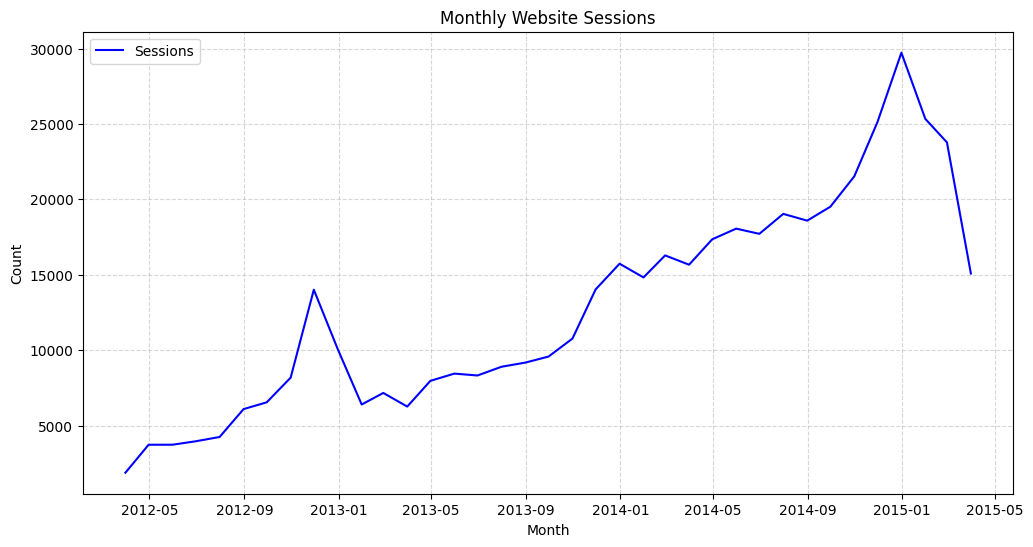

In [68]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_session_orders_toy_df["created_at"],
    monthly_session_orders_toy_df["total_sessions"],
    label="Sessions",
    color="blue"
)

plt.title("Monthly Website Sessions")
plt.xlabel("Month")
plt.ylabel("Count")
plt.legend()

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

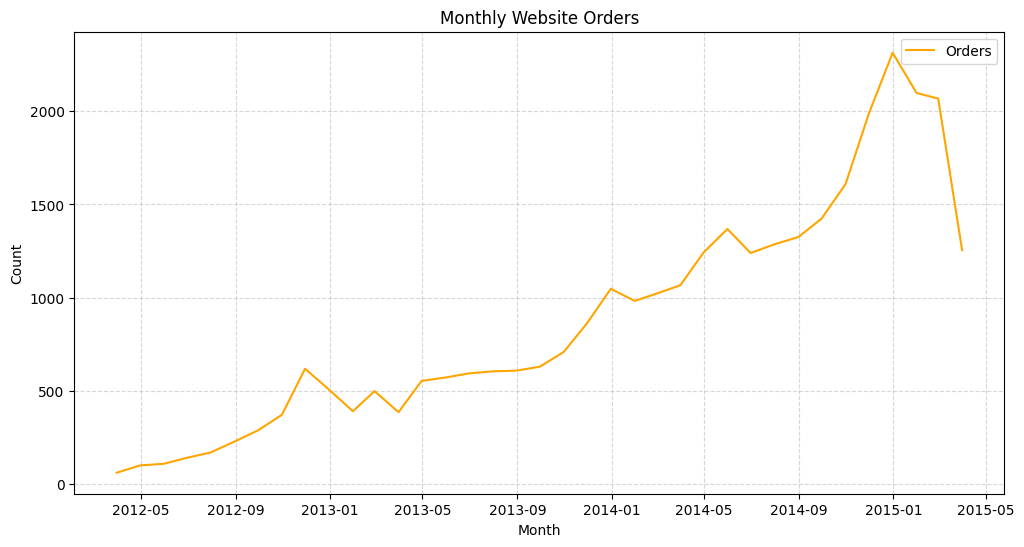

In [69]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_session_orders_toy_df["created_at"],
    monthly_session_orders_toy_df["total_orders"],
    label="Orders",
    color="orange"
)

plt.title("Monthly Website Orders")
plt.xlabel("Month")
plt.ylabel("Count")
plt.legend()

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**💡Insight:**  
Pertumbuhan kunjungan website dan volume pembelian menunjukkan kenaikan dari Mei 2012 hingga awal tahun 2015. Hal tersebut menunjukkan bahwa Toko Mainan sedang dalam fase *growth*.

Selain itu, dapat terlihat adanya pola musiman, dimana pada setiap Q4 tahunan terjadi lonjakan kunjungan website dan volume pembelian. Hal ini bisa dikaitkan dengan mulai masuknya musim liburan (terutama perayaan hari natal).


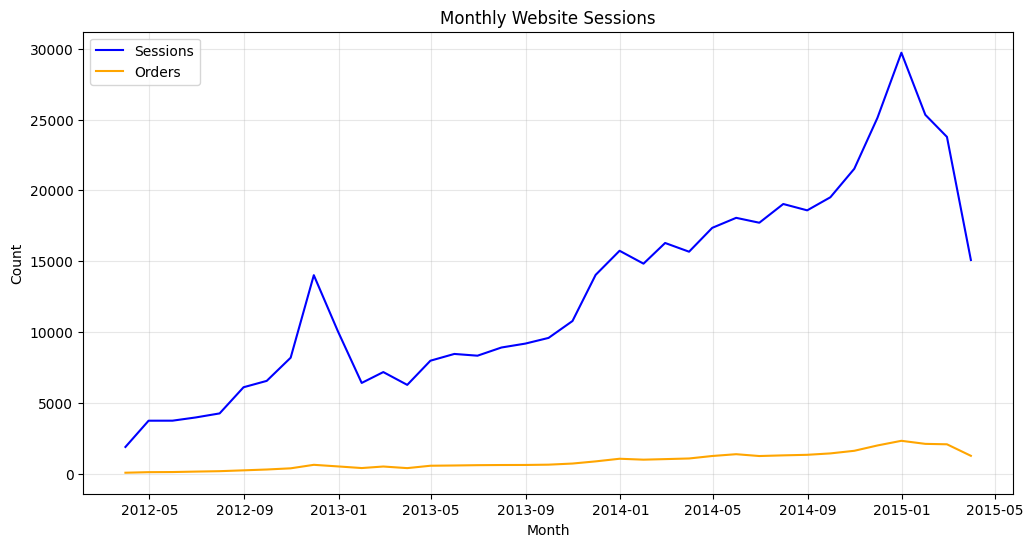

In [70]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_session_orders_toy_df["created_at"],
    monthly_session_orders_toy_df["total_sessions"],
    label="Sessions",
    color="blue"
)

plt.plot(
    monthly_session_orders_toy_df["created_at"],
    monthly_session_orders_toy_df["total_orders"],
    label="Orders",
    color="orange"
)

plt.title("Monthly Website Sessions")
plt.xlabel("Month")
plt.ylabel("Count")
plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

Dapat dilihat kedua Plot memiliki pola yang sama, akan tetapi tidak bisa jika langsung disatuin kedua plot karena berdasarkan `monthly_session_orders_toy_df.describe()` diatas:

- min website_session_id -> 1879
- max website_session_id -> 29722

- min order_id -> 60
- max order_id -> 2314

Maka akan dilakukan Min-Max Normalisasi untuk `monthly_session_orders_toy_df.describe()`

In [71]:
monthly_session_orders_toy_df["total_sessions_normalized"] = (
    monthly_session_orders_toy_df["total_sessions"]
    - monthly_session_orders_toy_df["total_sessions"].min()
) / (
    monthly_session_orders_toy_df["total_sessions"].max()
    - monthly_session_orders_toy_df["total_sessions"].min()
)

In [72]:
monthly_session_orders_toy_df["total_orders_normalized"] = (
    monthly_session_orders_toy_df["total_orders"]
    - monthly_session_orders_toy_df["total_orders"].min()
) / (
    monthly_session_orders_toy_df["total_orders"].max()
    - monthly_session_orders_toy_df["total_orders"].min()
)

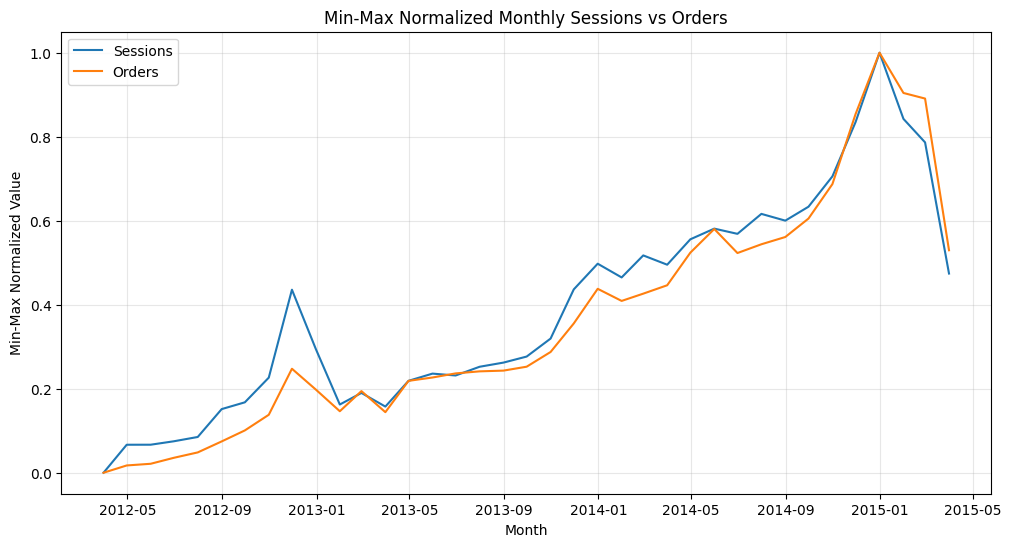

In [73]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_session_orders_toy_df["created_at"],
    monthly_session_orders_toy_df["total_sessions_normalized"],
    label="Sessions"
)

plt.plot(
    monthly_session_orders_toy_df["created_at"],
    monthly_session_orders_toy_df["total_orders_normalized"],
    label="Orders"
)

plt.title("Min-Max Normalized Monthly Sessions vs Orders")
plt.xlabel("Month")
plt.ylabel("Min-Max Normalized Value")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**💡Insight:**  
Grafik Min-Max Normalized membuktikan bahwa pergerakan jumlah sesi dan pesanan hampir berhimpitan sempurna. Artinya, pertumbuhan trafik yang masuk sangat berbanding lurus dengan pertumbuhan penjualan.



## Untuk Pertanyaan 2

In [74]:
monthly_session_orders_toy_df["conversion_rate"] = (
    monthly_session_orders_toy_df["total_orders"] / monthly_session_orders_toy_df["total_sessions"]
) * 100

In [75]:
monthly_session_orders_toy_df["conversion_rate"].describe()

,conversion_rate
count,37.000000
mean,6.181816
std,1.607545
min,2.651312
25%,5.023828
50%,6.653956
75%,7.127488
max,8.697115


In [76]:
monthly_session_orders_toy_df[monthly_session_orders_toy_df["conversion_rate"] == monthly_session_orders_toy_df["conversion_rate"].min()].head()

,created_at,total_sessions,total_orders,total_sessions_normalized,total_orders_normalized,conversion_rate
1,2012-04-30,3734,99,0.066624,0.017303,2.651312


In [77]:
monthly_session_orders_toy_df[monthly_session_orders_toy_df["conversion_rate"] == monthly_session_orders_toy_df["conversion_rate"].max()].head()

,created_at,total_sessions,total_orders,total_sessions_normalized,total_orders_normalized,conversion_rate
35,2015-02-28,23778,2068,0.786517,0.890861,8.697115


**💡Insight:**  
Rata-rata konversi dari kunjungan website menjadi pesanan adalah sebesar 6.18%, dengan tingkat konversi terendah ada pada bulan April 2012 sebesar 2.65% dan tingkat konversi tertinggi ada pada bulan Februari 2015 sebesar 8.69%

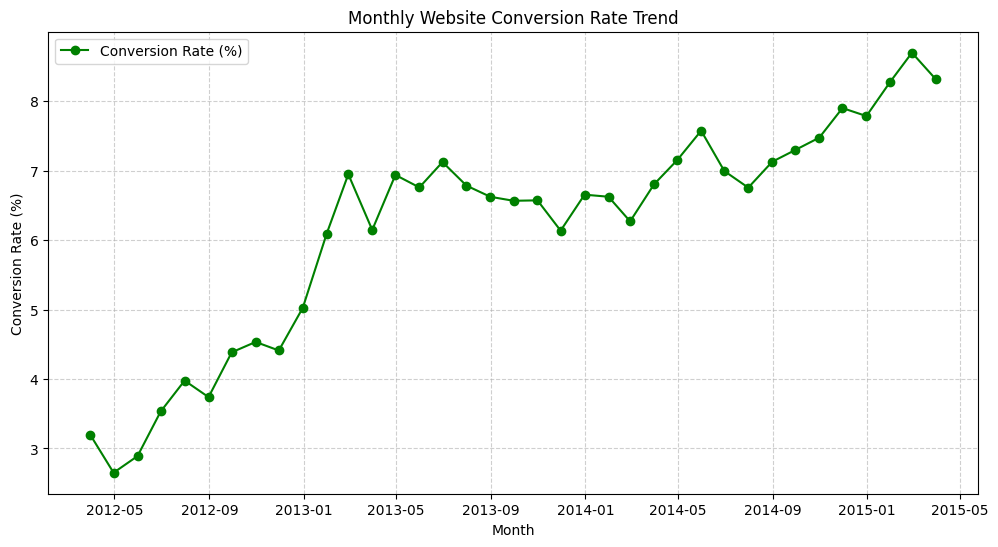

In [78]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_session_orders_toy_df["created_at"],
    monthly_session_orders_toy_df["conversion_rate"],
    label="Conversion Rate (%)",
    color="green",
    marker="o"
)

plt.title("Monthly Website Conversion Rate Trend")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()

**💡Insight:**  
Pada pertengahan hingga akhir tahun 2012, CVR tergolong rendah (berkisar di angka 2% - 4%). Namun, memasuki tahun 2013, terjadi lonjakan kenaikan yang sangat tajam dan cepat hingga menembus angka 6% - 7%.

Lalu, pada tahun 2013 hingga awal 2015, pergerakan garisnya menjadi jauh lebih landai dan stabil. Meskipun ada sedikit naik-turun bulanan, performa konversi website sudah matang dan konsisten.



## Untuk Pertanyaan 3

In [79]:
session_orders_toy_df = pd.merge(
    left=website_sessions_df,
    right=orders_df[['website_session_id', 'order_id', 'price_usd']],
    how="left",
    left_on="website_session_id",
    right_on="website_session_id"
)

In [80]:
session_orders_toy_df.head()


,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer,order_id,price_usd
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,NaN,NaN
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,NaN,NaN
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,NaN,NaN
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com,NaN,NaN
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com,NaN,NaN


In [81]:
marketing_channel_performance_df = session_orders_toy_df.groupby(['utm_source', 'utm_campaign']).agg(
    total_sessions=('website_session_id', 'count'),
    total_orders=('order_id', 'nunique'),
    total_revenue=('price_usd', 'sum')
).reset_index()

In [82]:
marketing_channel_performance_df['conversion_rate'] = (
    marketing_channel_performance_df['total_orders'] / marketing_channel_performance_df['total_sessions']
) * 100

In [83]:
marketing_channel_performance_df['revenue_per_session'] = (
    marketing_channel_performance_df['total_revenue'] / marketing_channel_performance_df['total_sessions']
)

In [84]:
marketing_channel_performance_df['channel_campaign'] = (
    marketing_channel_performance_df['utm_source'] + ' - ' + marketing_channel_performance_df['utm_campaign']
)

Jumlah Order berdasarkan Source dan Campaign

In [85]:
marketing_channel_performance_df.sort_values(by="total_orders", ascending=False)

,utm_source,utm_campaign,total_sessions,total_orders,total_revenue,conversion_rate,revenue_per_session,channel_campaign
3,gsearch,nonbrand,282706,18822,1124414.21,6.657800,3.977327,gsearch - nonbrand
4,no_data,no_data,83328,6118,371433.03,7.342070,4.457482,no_data - no_data
1,bsearch,nonbrand,54909,3818,225563.48,6.953323,4.107951,bsearch - nonbrand
2,gsearch,brand,33329,2511,151730.68,7.533979,4.552512,gsearch - brand
0,bsearch,brand,7914,701,43109.02,8.857720,5.447185,bsearch - brand
5,socialbook,desktop_targeted,5590,288,18516.10,5.152057,3.312361,socialbook - desktop_targeted
6,socialbook,pilot,5095,55,3743.23,1.079490,0.734687,socialbook - pilot


/tmp/ipykernel_1663/312995149.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


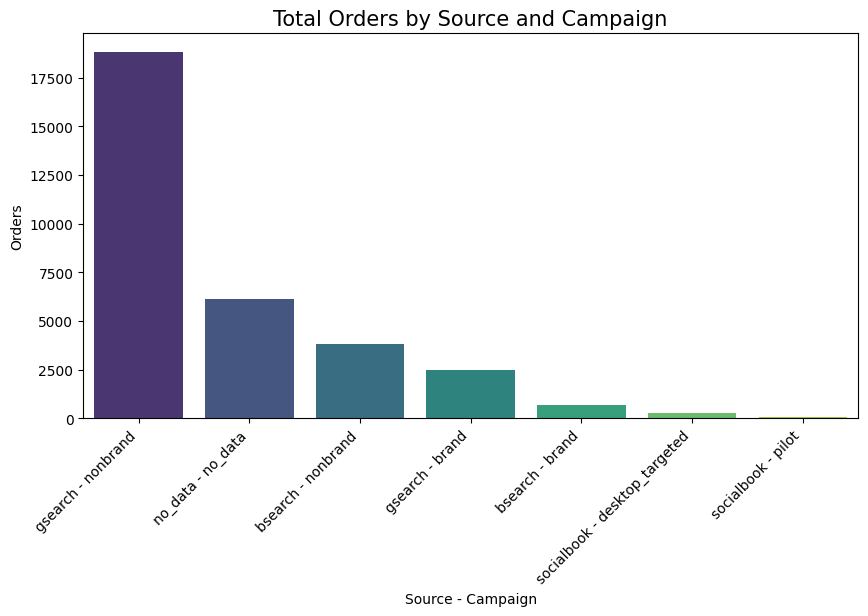

In [86]:
plt.figure(figsize=(10, 5))

sns.barplot(
    y="total_orders",
    x="channel_campaign",
    data=marketing_channel_performance_df.sort_values(by="total_orders", ascending=False),
    palette="viridis"
)
plt.title("Total Orders by Source and Campaign", loc="center", fontsize=15)
plt.ylabel("Orders")
plt.xlabel("Source - Campaign")

plt.xticks(rotation=45, ha='right')

plt.show()

**💡Insight:**  
Kombinasi `utm_source` gsearch dan `utm_campaign` nonbrand mendominasi perolehan transaksi dengan selisih yang sangat jauh dibandingkan saluran lain (mencapai lebih dari 18.000 pesanan). Hal tersebut menunjukkan bahwa saluran ini adalah motor penggerak utama volume penjualan perusahaan.

Jumlah Session berdasarkan Source dan Campaign

In [87]:
marketing_channel_performance_df.sort_values(by="total_sessions", ascending=False)

,utm_source,utm_campaign,total_sessions,total_orders,total_revenue,conversion_rate,revenue_per_session,channel_campaign
3,gsearch,nonbrand,282706,18822,1124414.21,6.657800,3.977327,gsearch - nonbrand
4,no_data,no_data,83328,6118,371433.03,7.342070,4.457482,no_data - no_data
1,bsearch,nonbrand,54909,3818,225563.48,6.953323,4.107951,bsearch - nonbrand
2,gsearch,brand,33329,2511,151730.68,7.533979,4.552512,gsearch - brand
0,bsearch,brand,7914,701,43109.02,8.857720,5.447185,bsearch - brand
5,socialbook,desktop_targeted,5590,288,18516.10,5.152057,3.312361,socialbook - desktop_targeted
6,socialbook,pilot,5095,55,3743.23,1.079490,0.734687,socialbook - pilot


/tmp/ipykernel_1663/3338715908.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


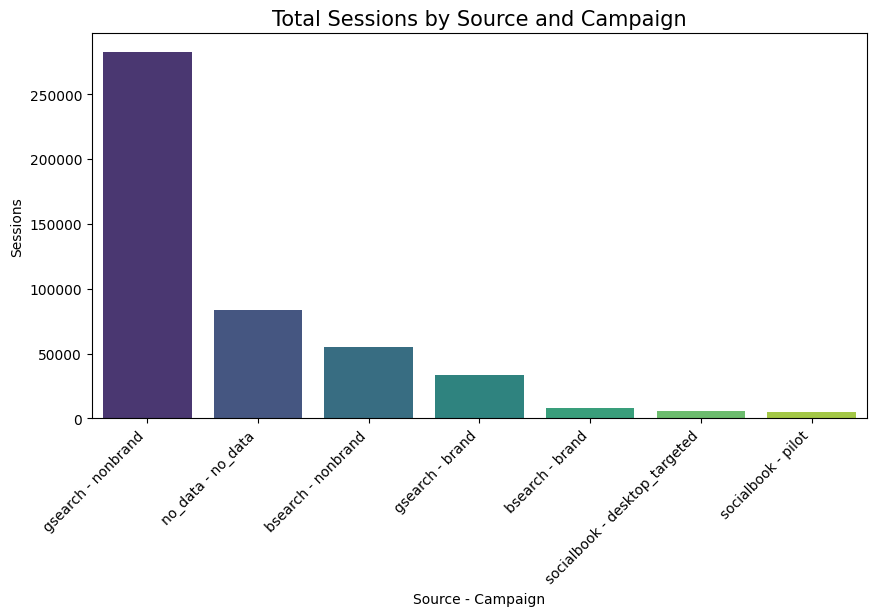

In [88]:
plt.figure(figsize=(10, 5))

sns.barplot(
    y="total_sessions",
    x="channel_campaign",
    data=marketing_channel_performance_df.sort_values(by="total_sessions", ascending=False),
    palette="viridis"
)
plt.title("Total Sessions by Source and Campaign", loc="center", fontsize=15)
plt.ylabel("Sessions")
plt.xlabel("Source - Campaign")

plt.xticks(rotation=45, ha='right')

plt.show()

**💡Insight:**  
Pola grafiknya hampir identik dengan total orders, di mana `utm_source` gsearch dan `utm_campaign` nonbrand mencatatkan kunjungan tertinggi. Hal ini membuktikan bahwa sebagian besar massa atau traffic awal website ditarik melalui saluran ini.

Jumlah Conversion Rate (CVR) berdasarkan Source dan Campaign

In [89]:
marketing_channel_performance_df.sort_values(by="conversion_rate", ascending=False)

,utm_source,utm_campaign,total_sessions,total_orders,total_revenue,conversion_rate,revenue_per_session,channel_campaign
0,bsearch,brand,7914,701,43109.02,8.857720,5.447185,bsearch - brand
2,gsearch,brand,33329,2511,151730.68,7.533979,4.552512,gsearch - brand
4,no_data,no_data,83328,6118,371433.03,7.342070,4.457482,no_data - no_data
1,bsearch,nonbrand,54909,3818,225563.48,6.953323,4.107951,bsearch - nonbrand
3,gsearch,nonbrand,282706,18822,1124414.21,6.657800,3.977327,gsearch - nonbrand
5,socialbook,desktop_targeted,5590,288,18516.10,5.152057,3.312361,socialbook - desktop_targeted
6,socialbook,pilot,5095,55,3743.23,1.079490,0.734687,socialbook - pilot


/tmp/ipykernel_1663/2312575194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


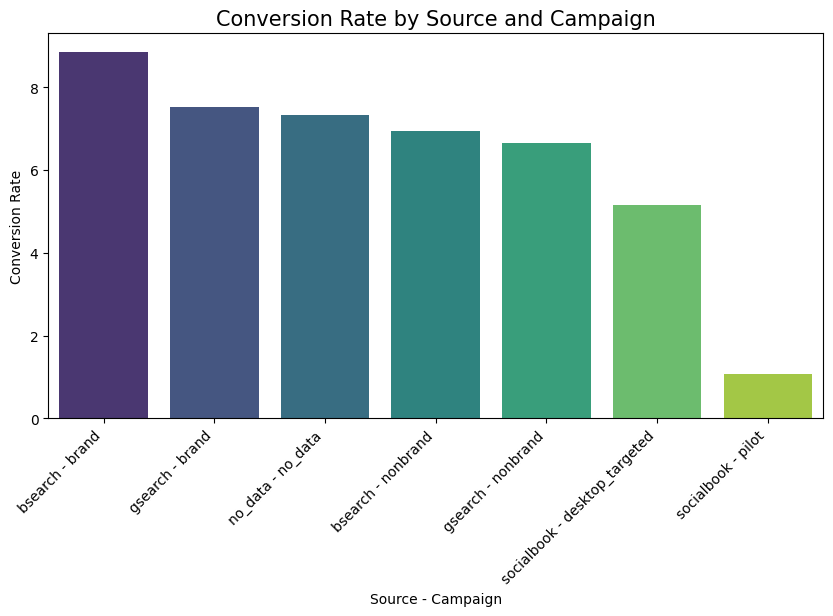

In [90]:
plt.figure(figsize=(10, 5))

sns.barplot(
    y="conversion_rate",
    x="channel_campaign",
    data=marketing_channel_performance_df.sort_values(by="conversion_rate", ascending=False),
    palette="viridis"
)
plt.title("Conversion Rate by Source and Campaign", loc="center", fontsize=15)
plt.ylabel("Conversion Rate")
plt.xlabel("Source - Campaign")

plt.xticks(rotation=45, ha='right')

plt.show()

**💡Insight:**  
Dari grafik dapat diketahui bahwa `utm_source` bsearch dan `utm_campaign` brand mencatatkan kunjungan tertinggi. Akan tetapi, `utm_source` gsearch dengan `utm_campaign` yang sama juga tidak tertinggal jauh.

Artinya, dapat ditarik kesimpulan bahwa pengguna yang benar-benar mencari merek mainan dari perusahaan ini di bearch atau gsearch lebih besar kemungkinannya untuk bertransaksi daripada pengguna yang mencari berdasarkan kata-kata generik (seperti = "mainan anak lucu")

In [91]:
marketing_channel_performance_df.sort_values(by="revenue_per_session", ascending=False)

,utm_source,utm_campaign,total_sessions,total_orders,total_revenue,conversion_rate,revenue_per_session,channel_campaign
0,bsearch,brand,7914,701,43109.02,8.857720,5.447185,bsearch - brand
2,gsearch,brand,33329,2511,151730.68,7.533979,4.552512,gsearch - brand
4,no_data,no_data,83328,6118,371433.03,7.342070,4.457482,no_data - no_data
1,bsearch,nonbrand,54909,3818,225563.48,6.953323,4.107951,bsearch - nonbrand
3,gsearch,nonbrand,282706,18822,1124414.21,6.657800,3.977327,gsearch - nonbrand
5,socialbook,desktop_targeted,5590,288,18516.10,5.152057,3.312361,socialbook - desktop_targeted
6,socialbook,pilot,5095,55,3743.23,1.079490,0.734687,socialbook - pilot


Jumlah Revenue Per Session berdasarkan Source dan Campaign

/tmp/ipykernel_1663/1474727697.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


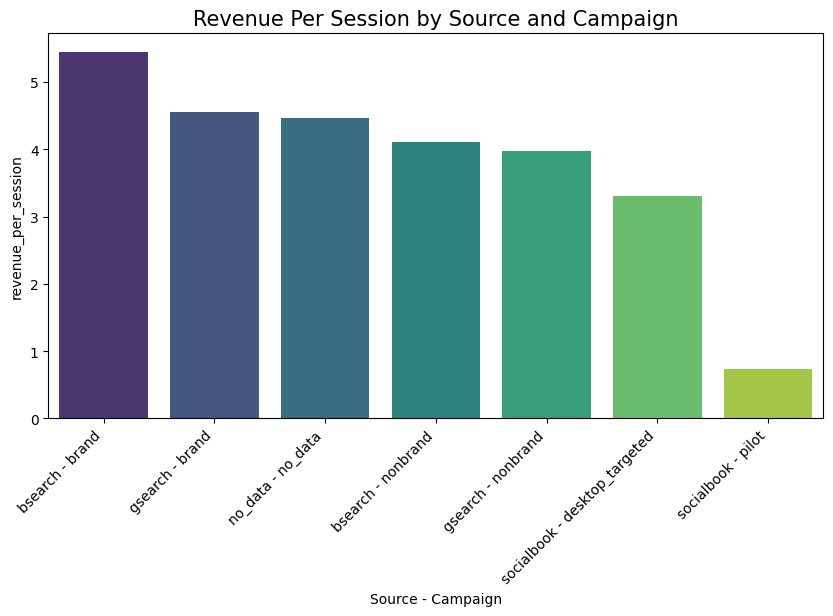

In [92]:
plt.figure(figsize=(10, 5))

sns.barplot(
    y="revenue_per_session",
    x="channel_campaign",
    data=marketing_channel_performance_df.sort_values(by="conversion_rate", ascending=False),
    palette="viridis"
)
plt.title("Revenue Per Session by Source and Campaign", loc="center", fontsize=15)
plt.ylabel("revenue_per_session")
plt.xlabel("Source - Campaign")

plt.xticks(rotation=45, ha='right')

plt.show()

**💡Insight:**  
Pola grafiknya hampir identik dengan CVR, di mana `utm_source` bsearch dan `utm_campaign` brand mencatatkan CVR tertinggi, lalu diikuti oleh `utm_source` gsearch dengan `utm_campaign` yang sama.

Artinya, dapat ditarik kesimpulan bahwa pengguna yang benar-benar mencari merek mainan dari perusahaan ini di bearch atau gsearch lebih besar rata-rata nominal transaksinya ($USD) daripada pengguna yang mencari berdasarkan kata-kata generik (seperti = "mainan anak lucu")



## Untuk Pertanyaan 4

In [93]:
monthly_toy_df = session_orders_toy_df.resample('M', on='created_at').agg(
    total_sessions=('website_session_id', 'count'),
    total_orders=('order_id', 'nunique'),
    total_revenue=('price_usd', 'sum')
).reset_index()

/tmp/ipykernel_1663/3407609554.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_toy_df = session_orders_toy_df.resample('M', on='created_at').agg(


In [94]:
monthly_toy_df['average_order_value'] = monthly_toy_df['total_revenue'] / monthly_toy_df['total_orders']
monthly_toy_df['revenue_per_session'] = monthly_toy_df['total_revenue'] / monthly_toy_df['total_sessions']

In [95]:
monthly_toy_df

,created_at,total_sessions,total_orders,total_revenue,average_order_value,revenue_per_session
0,2012-03-31,1879,60,2999.40,49.990000,1.596275
1,2012-04-30,3734,99,4949.01,49.990000,1.325391
2,2012-05-31,3736,108,5398.92,49.990000,1.445107
3,2012-06-30,3963,140,6998.60,49.990000,1.765985
4,2012-07-31,4249,169,8448.31,49.990000,1.988305
5,2012-08-31,6097,228,11397.72,49.990000,1.869398
6,2012-09-30,6546,287,14347.13,49.990000,2.191740
7,2012-10-31,8183,371,18546.29,49.990000,2.266441
8,2012-11-30,14011,618,30893.82,49.990000,2.204969
9,2012-12-31,10072,506,25294.94,49.990000,2.511412


Tren AOV Bulanan

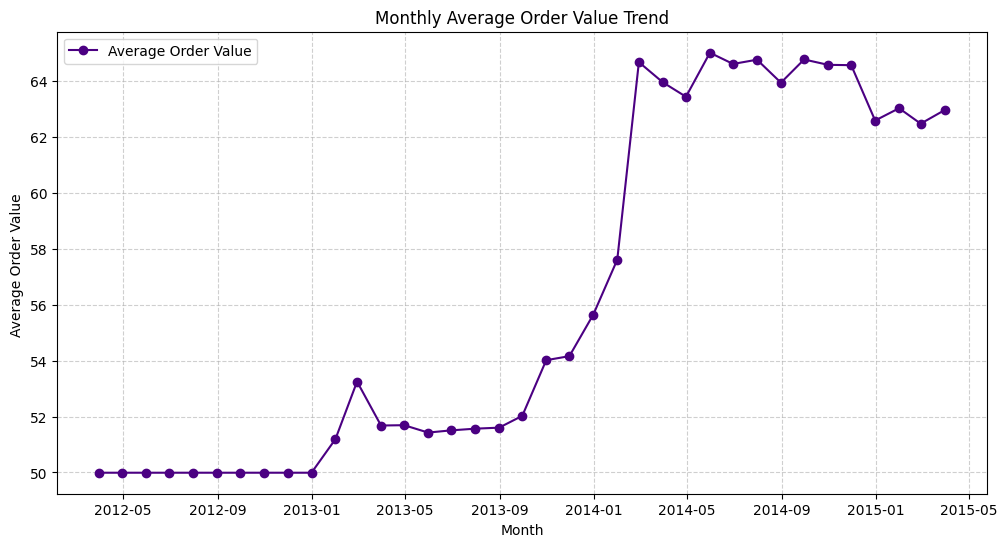

In [96]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_toy_df["created_at"],
    monthly_toy_df["average_order_value"],
    label="Average Order Value",
    color="indigo",
    marker="o"
)

plt.title("Monthly Average Order Value Trend")
plt.xlabel("Month")
plt.ylabel("Average Order Value ")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()

**💡Insight:**  
Pada Awal dari Mei 2012 sampai Januari 2013, Average Order Value konstan di angka 50. Sedikit kenaikan AOV Terjadi di Februari 2013, lalu menurun dan konstan kembali di angka 50-51 USD. Kenaikan AOV signifikan terjadi pada Oktober 2013 dari 45 USD merangkak naik menjadi 65 USD pada Maret 2014. Kemudian mengalami stagnasi pada sekitaran 63 sampai 65 USD sampai pada Desember 2015. Penurunan AOV terjadi lagi pada Januari 2015 dan mengalam stagnasi di 62-63 USD sampai akhir dataset

Tren RPS Bulanan

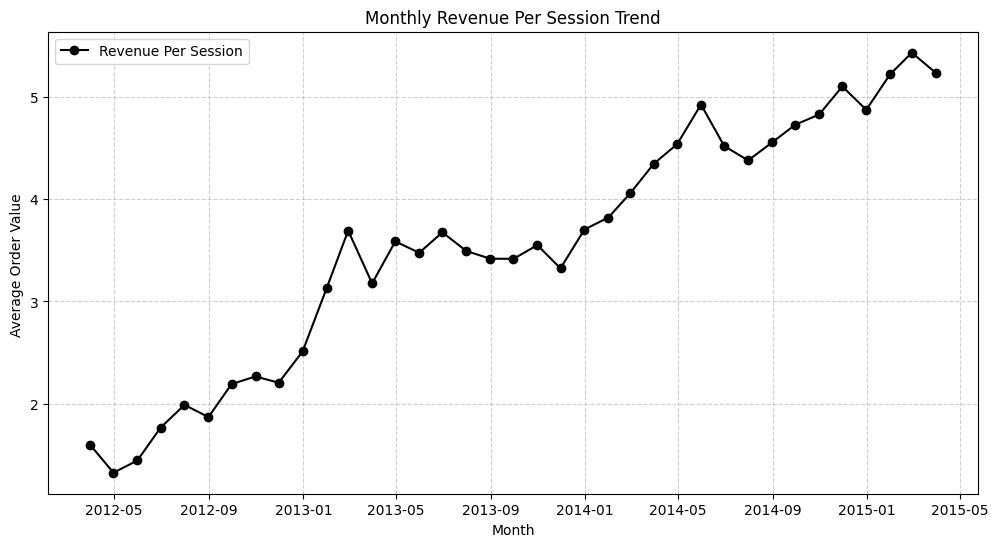

In [97]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_toy_df["created_at"],
    monthly_toy_df["revenue_per_session"],
    label="Revenue Per Session",
    color="black",
    marker="o"
)

plt.title("Monthly Revenue Per Session Trend")
plt.xlabel("Month")
plt.ylabel("Average Order Value ")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()

**💡Insight:**  

Pendapatan rata-rata per kunjungan menunjukkan grafik uptrend yang sangat konsisten dari waktu ke waktu—melonjak dari sekitar 1.5 USD di awal 2012 menjadi lebih dari 5 USD pada tahun 2015.

# Kesimpulan

**Pertanyaan 1**  
Pertumbuhan kunjungan website dan volume pembelian menunjukkan tren peningkatan yang konsisten dari Mei 2012 hingga awal tahun 2015, yang mengindikasikan bahwa Toko Mainan sedang berada dalam fase growth. Hal tersebut semakin diperkuat oleh grafik Min-Max Normalized untuk kedua kolom yang menunjukkan pola jumlah sesi dan jumlah pesanan berhimpitan hampir sempurna, yang menandakan pertumbuhan trafik website berbanding lurus secara linier dengan pertumbuhan penjualan perusahaan.

**Pertanyaan 2**  
Rata-rata tingkat konversi dari kunjungan website menjadi pesanan adalah sebesar 6.18%, dengan capaian terendah pada bulan April 2012 sebesar 2.65% dan tertinggi pada bulan Februari 2015 sebesar 8.69%. Dari segi tren, tingkat konversi yang sebelumnya tergolong rendah di kisaran 2%-4% pada pertengahan hingga akhir tahun 2012 mengalami lonjakan tajam hingga menembus angka 6%-7% pada tahun 2013, sebelum akhirnya bergerak jauh lebih stabil, matang, dan konsisten hingga awal tahun 2015.

**Pertanyaan 3**  
Kombinasi saluran pemasaran `utm_source` gsearch dan `utm_campaign` nonbrand terbukti paling efektif sebagai roda penggerak utama volume penjualan serta penarik traffic awal website karena mendominasi perolehan total pesanan dan kunjungan website secara masif.

Namun, dari sisi kualitas dan efisiensi moneter, saluran berbasis pencarian merek (`utm_campaign` brand) seperti pada `utm_source` bsearch dan gsearch menunjukkan performa terbaik karena mencatatkan tingkat konversi (Conversion Rate) serta pendapatan per sesi (Revenue Per Session) tertinggi. Hal ini mengindikasikan bahwa pengguna yang mencari merek secara langsung di internet jauh lebih besar kemungkinannya untuk bertransaksi dengan nominal rata-rata yang lebih tinggi dibandingkan pencarian kata kunci generik.

**Pertanyaan 4**

Perkembangan pendapatan rata-rata per pesanan (Average Order Value/AOV) tercatat konstan di angka 50 USD dari Mei 2012 hingga Januari 2013, sempat mengalami sedikit kenaikan sebelum stabil kembali di kisaran 50-51 USD, lalu melonjak signifikan mulai Oktober 2013 hingga mencapai 65 USD pada Maret 2014 sebelum akhirnya mengalami stagnasi di kisaran 62 hingga 65 USD hingga akhir periode dengan sedikit penurunan di awal tahun 2015. Sementara itu, perkembangan pendapatan rata-rata per kunjungan atau sesi website (Revenue Per Session/RPS) menunjukkan grafik uptrend yang sangat konsisten dari waktu ke waktu, di mana nilainya melonjak naik dari sekitar 1.5 USD pada awal tahun 2012 hingga melampaui 5 USD pada tahun 2015.